# PASTIS Crop-Type Classification — Exploration & Training

Solafune Geo Data Scientist assignment. This notebook covers the assignment's
task **A (data loading & preparation)** and **B (exploratory data analysis)**
in full, and orchestrates tasks **C-F (splits, training, evaluation,
visualization)** by calling into the reusable pipeline code in `src/`
(the heavy lifting — feature extraction, model training, metrics — lives in
`.py` modules so it can be run outside the notebook via `src/train.py` /
`src/evaluate.py` as well; see `README.md`).

**Dataset**: a 102-patch subset of PASTIS (Sentinel-2 time series, 128x128 px
@ 10m, semantic crop-type labels only — no per-parcel instance IDs were
provided, so this analysis works at the pixel/patch level rather than
per-parcel).

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from data_loading import (
    load_config, load_metadata, list_patch_ids, load_s2, load_target,
    get_dates, inspect_dataset, class_pixel_counts, patch_ids_for_folds,
)
from preprocessing import to_reflectance, compute_ndvi

cfg = load_config("configs/config.yaml")
gdf = load_metadata(cfg)
patch_ids = list_patch_ids(cfg)
class_names = cfg["classes"]
fig_dir = Path("../outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

print(f"{len(patch_ids)} patches available (S2 + annotation both present).")

102 patches available (S2 + annotation both present).


## A. Data Loading & Preparation

We load each patch's Sentinel-2 time series (`DATA_S2/S2_<id>.npy`) and its
semantic label map (`ANNOTATIONS/TARGET_<id>.npy`), plus per-patch metadata
(fold assignment, acquisition dates, tile, parcel count) from
`metadata.geojson`. `src/data_loading.py` centralizes all of this so every
other script/notebook cell reads data the same way.

In [2]:
summary = inspect_dataset(cfg, gdf)
print("Number of patches:               ", summary["n_patches"])
print("S2 array shape (C, H, W), per obs:", summary["s2_spatial_band_shapes"])
print("S2 dtype:                        ", summary["s2_dtypes"])
print("Target array shape (H, W):       ", summary["target_shapes"])
print("Target dtype:                    ", summary["target_dtypes"])
print("Observations per patch (min/max):", summary["n_observations_min"], "/", summary["n_observations_max"])
print("Sentinel-2 tile(s) covered:      ", summary["tiles"])
print("Patches per official fold:       ", summary["folds"])

Number of patches:                102
S2 array shape (C, H, W), per obs: {(10, 128, 128)}
S2 dtype:                         {'int16'}
Target array shape (H, W):        {(128, 128)}
Target dtype:                     {'uint8'}
Observations per patch (min/max): 46 / 46
Sentinel-2 tile(s) covered:       ['t31tfm']
Patches per official fold:        {1: 20, 2: 23, 3: 23, 4: 18, 5: 18}


**Observations**: every one of the 102 patches has exactly **46** Sentinel-2
observations spanning **2018-09-20 to 2019-10-25** (~13 months, one full
crop-growing season plus margin) — so, unusually for PASTIS, there is no
ragged/variable sequence length to handle in this subset. All patches come
from a single tile (`t31tfm`), and the official 5-fold spatial CV split
(`Fold` 1-5) is close to balanced (18-23 patches/fold).

Sentinel-2 arrays are `int16` reflectance scaled by 10000 (raw range
approx. [-105, 14924] on the sample patch inspected — small negatives are
normal atmospheric-correction noise near zero reflectance, not a data error).
Labels are `uint8`, one semantic class ID per pixel; only the 0th
(semantic) annotation layer was provided, so no per-parcel instance IDs are
available — the modelling task here is therefore **pixel/patch-level
semantic segmentation**, not parcel classification, despite the AOI
literally being organized into agricultural parcels.

**Sampling strategy** (task A): rather than materializing a full
128x128x102-pixel table upfront, `src/preprocessing.py`
(`build_pixel_feature_table`) draws a class-stratified sample of up to 400
pixels per class per patch when building ML training features. This keeps
every patch and every class represented while bounding the majority classes
(background/meadow) — see that module's docstring for the full rationale.
The DL track instead consumes the full `(T, C, H, W)` patch tensor directly
(no sampling needed at the patch level).

## B. Exploratory Data Analysis

### Class distribution

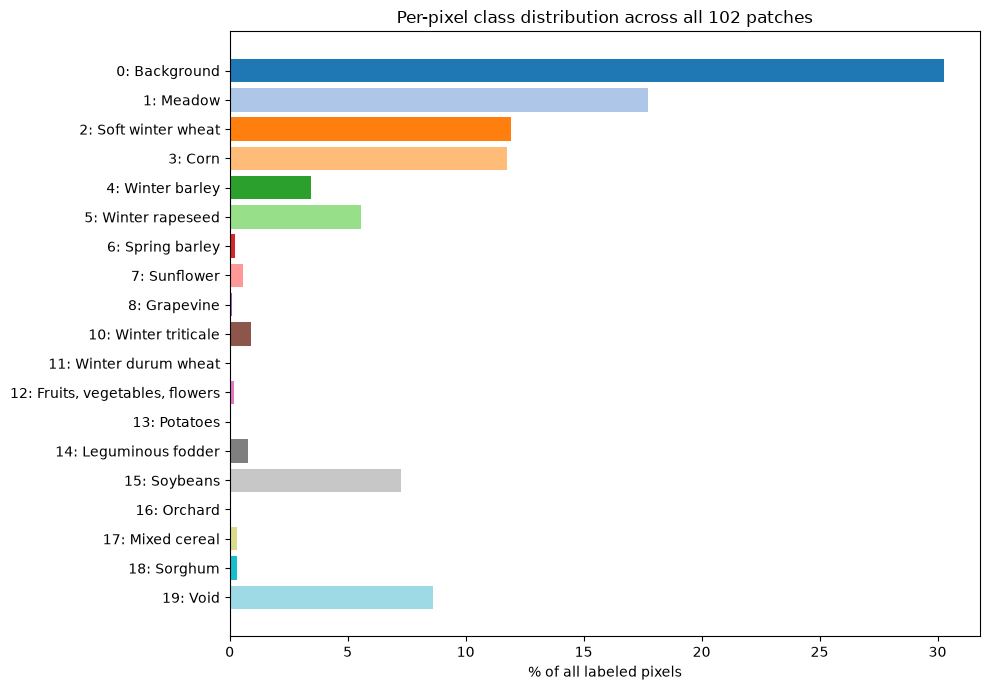

,class_id,class_name,pixel_count,pct
0,0,Background,506141,30.286662
1,1,Meadow,296576,17.746630
2,2,Soft winter wheat,199108,11.914302
3,3,Corn,196704,11.770450
18,19,Void,144087,8.621934
14,15,Soybeans,121560,7.273955
5,5,Winter rapeseed,92912,5.559704
4,4,Winter barley,57381,3.433587
9,10,Winter triticale,15215,0.910441
13,14,Leguminous fodder,12634,0.755998


In [3]:
counts = class_pixel_counts(cfg)
total = sum(counts.values())
order = sorted(counts.keys())
labels = [f"{c}: {class_names[c]}" for c in order]
pct = [counts[c] / total * 100 for c in order]

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(order)))
ax.barh(labels, pct, color=colors)
ax.set_xlabel("% of all labeled pixels")
ax.set_title(f"Per-pixel class distribution across all {len(patch_ids)} patches")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(fig_dir / "class_distribution.png", dpi=120)
plt.show()

dist_table = pd.DataFrame({"class_id": order, "class_name": [class_names[c] for c in order],
                            "pixel_count": [counts[c] for c in order], "pct": pct})
dist_table.to_csv("../outputs/metrics/class_distribution.csv", index=False)
dist_table.sort_values("pct", ascending=False)

Class imbalance is severe: **Background (30.3%)**, **Meadow (17.8%)**,
**Soft winter wheat (11.9%)** and **Corn (11.8%)** together cover ~72% of
all labeled pixels, while classes like Grapevine, Winter durum wheat,
Potatoes and Orchard each account for **<0.1%** of pixels (Orchard is
effectively absent from this 102-patch subset — 0.00%, Beet — class 9 — does
not appear at all). ~8.6% of pixels carry the **void label (19)**, i.e. no
usable ground truth. This directly motivates: (a) using **macro-F1** rather
than overall accuracy as the headline metric, since accuracy would be
dominated by background/meadow/wheat/corn, (b) class-weighted training for
the ML track, and (c) treating the rarest classes' metrics with caution —
a handful of patches determine their entire test-set support.

### Sample patches — Sentinel-2 RGB composite vs. ground-truth labels

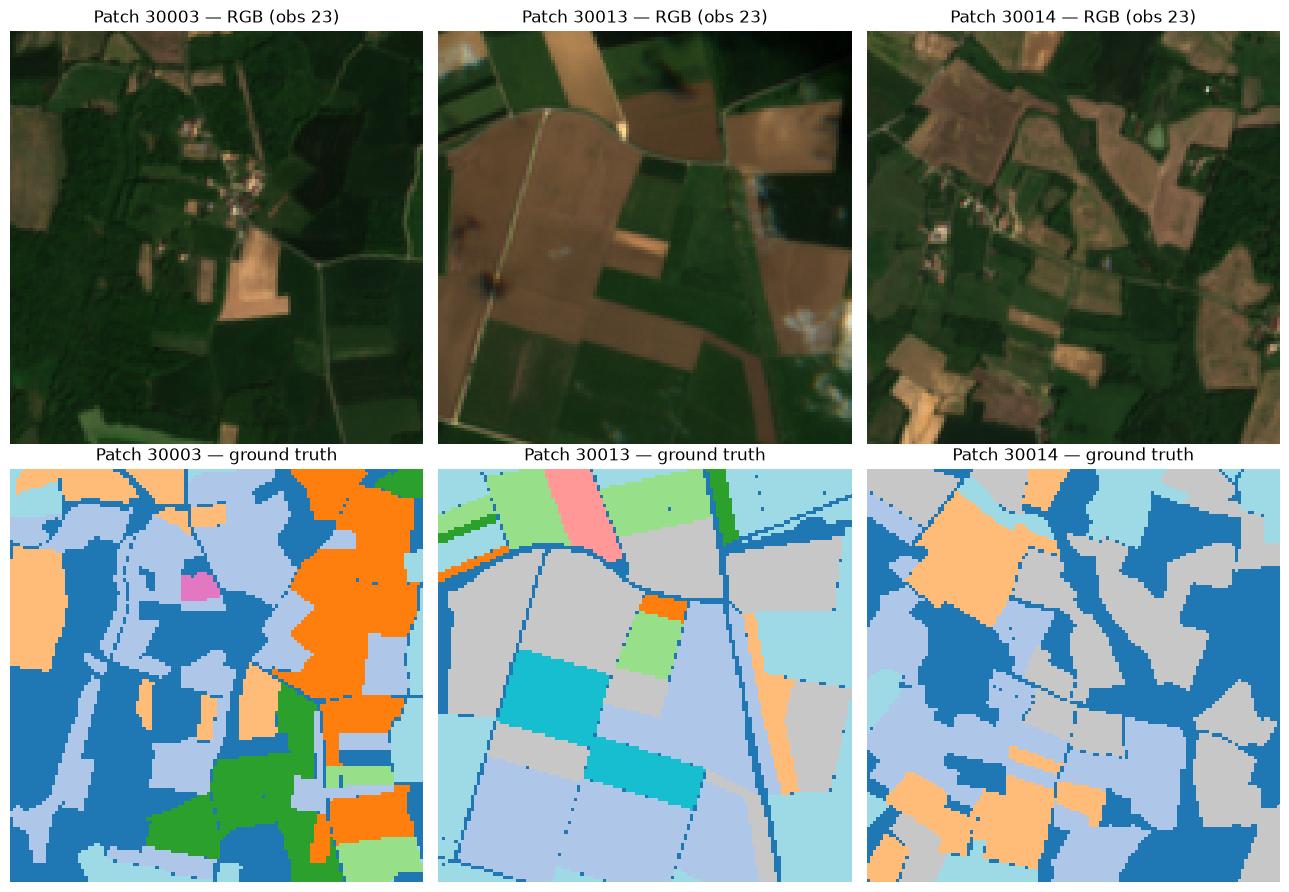

In [4]:
sample_ids = patch_ids[:3]
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for i, pid in enumerate(sample_ids):
    s2 = load_s2(cfg, pid)
    tgt = load_target(cfg, pid)
    refl = to_reflectance(s2)
    rgb_idx = cfg["rgb_bands"]
    mid_t = s2.shape[0] // 2
    rgb = refl[mid_t][rgb_idx].transpose(1, 2, 0)
    rgb = np.clip(rgb / 0.3, 0, 1)  # simple linear stretch for display

    axes[0, i].imshow(rgb)
    axes[0, i].set_title(f"Patch {pid} — RGB (obs {mid_t})")
    axes[0, i].axis("off")

    axes[1, i].imshow(tgt, cmap="tab20", vmin=0, vmax=19)
    axes[1, i].set_title(f"Patch {pid} — ground truth")
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig(fig_dir / "sample_patches_rgb_labels.png", dpi=120)
plt.show()

RGB composites (bands B4/B3/B2, mid-season observation) show clear
agricultural parcel boundaries that line up well with the label polygons —
confirming labels are spatially well-registered to the imagery. Patch 30013
shows small bright/white blobs consistent with cloud or haze contamination
on that particular date (a single mid-season frame, not necessarily
representative of the whole time series for that patch).

### NDVI phenology profiles by crop class

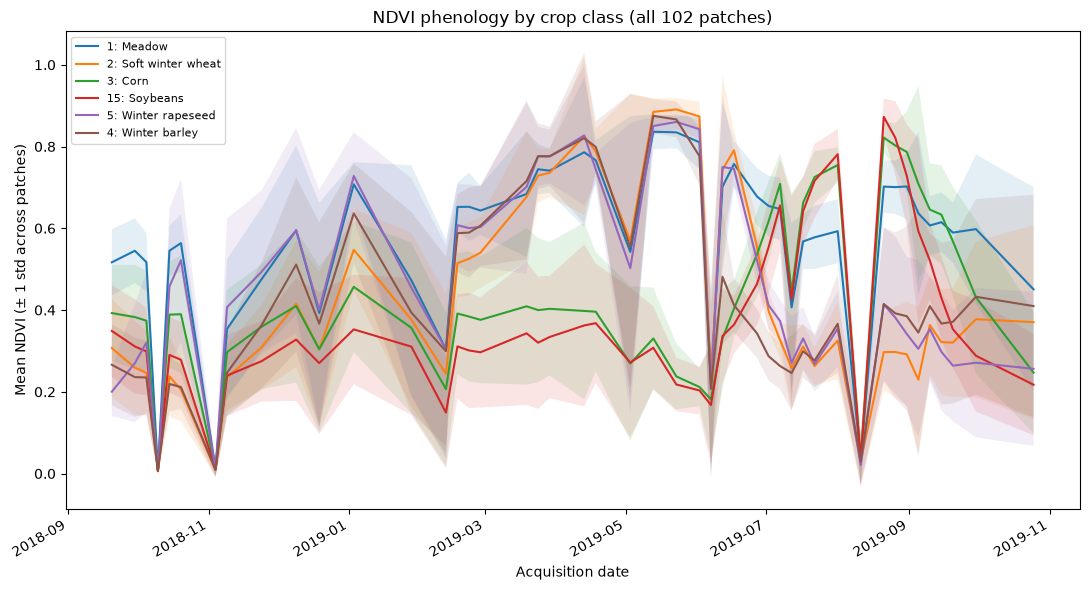

In [5]:
major_classes = [c for c, _ in Counter(counts).most_common(9) if c not in (cfg["background_class"], cfg["void_class"])][:6]

ndvi_by_class = {c: [] for c in major_classes}
for pid in patch_ids:
    s2 = to_reflectance(load_s2(cfg, pid))
    tgt = load_target(cfg, pid)
    ndvi = compute_ndvi(s2)
    for c in major_classes:
        mask = tgt == c
        if mask.sum() == 0:
            continue
        ndvi_by_class[c].append(ndvi[:, mask].mean(axis=1))

dates = get_dates(gdf, patch_ids[0])  # identical calendar for every patch in this subset
fig, ax = plt.subplots(figsize=(11, 6))
for c in major_classes:
    arr = np.array(ndvi_by_class[c])
    mean_curve, std_curve = arr.mean(axis=0), arr.std(axis=0)
    ax.plot(dates, mean_curve, label=f"{c}: {class_names[c]}")
    ax.fill_between(dates, mean_curve - std_curve, mean_curve + std_curve, alpha=0.12)
ax.set_xlabel("Acquisition date")
ax.set_ylabel("Mean NDVI (± 1 std across patches)")
ax.set_title(f"NDVI phenology by crop class (all {len(patch_ids)} patches)")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(fig_dir / "ndvi_phenology_by_class.png", dpi=120)
plt.show()

Clear, physically-meaningful phenological signatures emerge even
without a trained model: **winter crops** (wheat, barley, rapeseed) green up
in autumn/winter, peak in spring, then senesce and drop sharply before
summer harvest; **summer crops** (corn, soybean) stay near-flat/low through
winter and green up sharply from ~May, peaking in **July-August** —
this is the core signal any classifier here has to exploit. There are also
several sharp, **simultaneous** NDVI dips across *every* class at the same
dates — these are almost certainly **cloud-contaminated acquisitions**
rather than real vegetation changes (see Data Quality Checks below), and are
a source of noise for both per-pixel temporal features and any DL model
that doesn't explicitly mask clouds.

### AOI extent / geographic coverage

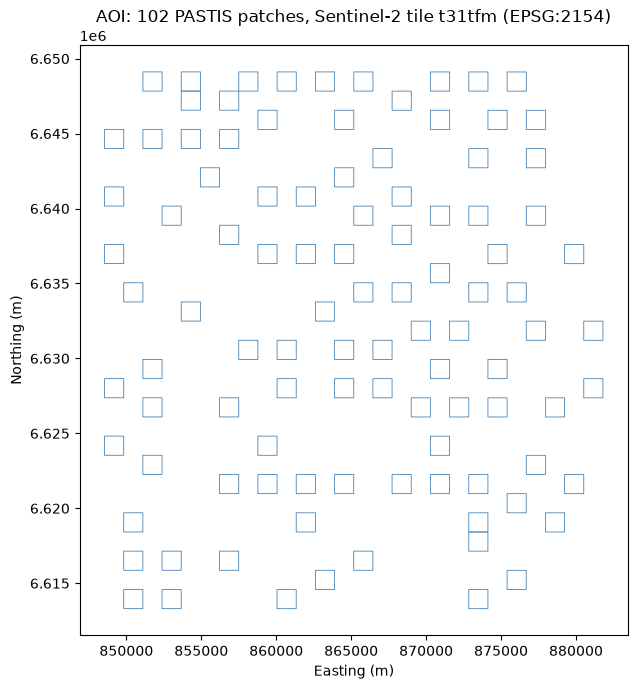

CRS: EPSG:2154  (Lambert-93, the French national reference system)
Bounding box: 33.3 km x 35.8 km, sparsely covered by 1.28km x 1.28km patches
Each patch covers 1.64 km^2 -> 102 patches = 167.1 km^2 imaged in total


In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
gdf.plot(ax=ax, facecolor="none", edgecolor="steelblue", linewidth=0.6)
tile_name = gdf["TILE"].unique()[0]
ax.set_title(f"AOI: {len(gdf)} PASTIS patches, Sentinel-2 tile {tile_name} ({gdf.crs})")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.savefig(fig_dir / "aoi_extent.png", dpi=120)
plt.show()

bounds = gdf.total_bounds
width_km, height_km = (bounds[2]-bounds[0])/1000, (bounds[3]-bounds[1])/1000
print(f"CRS: {gdf.crs}  (Lambert-93, the French national reference system)")
print(f"Bounding box: {width_km:.1f} km x {height_km:.1f} km, sparsely covered by 1.28km x 1.28km patches")
print(f"Each patch covers {128*128*100/1e6:.2f} km^2 -> {len(gdf)} patches = {len(gdf)*128*128*100/1e6:.1f} km^2 imaged in total")

The 102 patches are scattered non-contiguously across a **~33 km x
36 km** bounding box in Lambert-93 (EPSG:2154) coordinates, within a single
Sentinel-2 tile — consistent with PASTIS's original sparse-sampling strategy
for spatial diversity rather than one contiguous AOI. Without external
lookup, tile `t31tfm` is in mainland France (Lambert-93 easting ~850-882 km);
the mixed wheat/corn/rapeseed/meadow/soybean composition and autumn-sown
winter-cereal phenology are typical of temperate-zone mixed arable farming.

### Data quality checks

In [7]:
# 1. Sequence length variability (already summarized above: constant 46 across all patches)
obs_counts = summary["n_observations_per_patch"]
print("Sequence length variability: all", len(set(obs_counts.values())) == 1, "-> every patch has", list(set(obs_counts.values())), "observations")

# 2. Likely cloud-contaminated acquisitions: mean NDVI across ALL classes/patches, per date
all_ndvi_by_date = []
for pid in patch_ids[:30]:  # sample for speed; the dip pattern is already visible dataset-wide
    s2 = to_reflectance(load_s2(cfg, pid))
    ndvi = compute_ndvi(s2)
    all_ndvi_by_date.append(ndvi.mean(axis=(1, 2)))
all_ndvi_by_date = np.array(all_ndvi_by_date)
mean_ndvi_per_date = all_ndvi_by_date.mean(axis=0)
suspect_dates_idx = np.where(mean_ndvi_per_date < np.percentile(mean_ndvi_per_date, 15))[0]
print("Dates with unusually low mean NDVI across patches (likely cloud/haze):")
for i in suspect_dates_idx:
    print(f"  obs {i:2d}  {dates[i]}  mean NDVI={mean_ndvi_per_date[i]:.3f}")

# 3. Background / void ratio per patch
bg_ratios, void_ratios = [], []
for pid in patch_ids:
    tgt = load_target(cfg, pid)
    bg_ratios.append((tgt == cfg["background_class"]).mean())
    void_ratios.append((tgt == cfg["void_class"]).mean())
print(f"\nBackground pixel share per patch: mean={np.mean(bg_ratios):.2%}, max={np.max(bg_ratios):.2%}")
print(f"Void pixel share per patch:       mean={np.mean(void_ratios):.2%}, max={np.max(void_ratios):.2%}")

# 4. Parcel count / cover from metadata (proxy for label granularity / how "clean" a patch is)
print(f"\nN_Parcel per patch: min={gdf['N_Parcel'].min()}, median={gdf['N_Parcel'].median():.0f}, max={gdf['N_Parcel'].max()}")
print(f"Parcel_Cover per patch: mean={gdf['Parcel_Cover'].mean():.2%} (fraction of patch area assigned to a labeled parcel)")

Sequence length variability: all True -> every patch has [46] observations


Dates with unusually low mean NDVI across patches (likely cloud/haze):
  obs  3  2018-10-10  mean NDVI=0.008
  obs  6  2018-11-04  mean NDVI=0.012
  obs  7  2018-11-09  mean NDVI=0.299
  obs 13  2019-02-12  mean NDVI=0.243
  obs 26  2019-06-07  mean NDVI=0.247
  obs 32  2019-07-12  mean NDVI=0.343
  obs 36  2019-08-11  mean NDVI=0.031

Background pixel share per patch: mean=30.29%, max=66.68%
Void pixel share per patch:       mean=8.62%, max=29.17%

N_Parcel per patch: min=21, median=48, max=82
Parcel_Cover per patch: mean=70.50% (fraction of patch area assigned to a labeled parcel)


- **Sequence length**: uniform (46/patch) in this subset — no padding/
  masking needed for the DL track's temporal dimension, simplifying batching.
- **Cloud contamination**: several acquisition dates show a sharp,
  dataset-wide NDVI drop — consistent with cloud/haze rather than genuine
  vegetation change (real phenology doesn't move in lockstep across every
  crop type on a single day). These dates act as noise injected uniformly
  into the per-pixel temporal statistics (mean/std/slope) used by the ML
  track, and as noisy frames for the DL track unless a temporal
  attention/pooling mechanism can learn to downweight them.
- **Background/void pixels**: background is a legitimate land-cover class
  (non-agricultural or unclassified land within a patch) and void marks
  genuinely unlabeled pixels; both should be handled deliberately —
  background is kept as a real training class, void is excluded from both
  training and evaluation.
- **Parcel granularity**: patches have tens to ~100+ parcels each, with
  `Parcel_Cover` indicating what fraction of each patch is actually inside a
  labeled parcel — the remainder is background/other land cover.

### Time-series decomposition, trend & change detection

**Can we run a classical seasonal-trend decomposition (STL) or BFAST-style
change detection here? No — and it is worth stating why rather than producing
numbers that look meaningful and are not.**

| Requirement | This dataset |
|---|---|
| STL / `seasonal_decompose`: ≥2 full periods to separate trend from seasonal | **1.10 cycles** (400 days) |
| STL: evenly spaced samples | **irregular**, 5–25 day gaps |
| BFAST change detection: multi-year series to locate abrupt land-cover change | **one season** |

With 1.1 cycles, any "trend" component is not identifiable from the seasonal
term — the two are confounded, so an STL output here would be an artifact of
the window length, not a property of the crops.

**What *is* valid on a single, irregularly-sampled season:**

1. **Harmonic (Fourier) decomposition** — fits sinusoids of known annual period
   by least squares. Handles irregular sampling natively (the design matrix is
   built from real acquisition dates, not sample index) and needs only one
   cycle. It decomposes each curve into *mean level*, *amplitude*, and
   **phase** — i.e. **when** the peak occurs — plus a residual.
2. **Iterative outlier rejection (HANTS)** — cloud only ever *depresses* NDVI,
   so fitting, discarding strongly negative residuals and refitting both
   reconstructs a cloud-free curve and detects the contaminated dates. This is
   principled change/anomaly detection in the sense that actually applies here.
3. **Phenological metrics** — start/peak/end of season, amplitude, seasonal
   integral: the standard TIMESAT descriptors of a crop calendar.

Implemented in `src/phenology.py`.

In [8]:
from phenology import harmonic_fit, phenology_metrics, days_from_dates
import matplotlib.dates as mdates

dates_all = get_dates(gdf, patch_ids[0])
days = days_from_dates(dates_all)

# class-mean NDVI curve pooled over all patches (uses the cached NDVI cubes)
from preprocessing import patch_ndvi_series
sums, cnts = {}, {}
for p in patch_ids:
    ndvi, _ = patch_ndvi_series(cfg, p)
    tgt = load_target(cfg, p)
    for c in np.unique(tgt):
        if c in (cfg["background_class"], cfg["void_class"]):
            continue
        m = tgt == c
        sums[c] = sums.get(c, 0) + ndvi[:, m].sum(axis=1)
        cnts[c] = cnts.get(c, 0) + m.sum()
curves = {c: sums[c] / cnts[c] for c in sums if cnts[c] >= 2000}
print(f"{len(curves)} classes with >=2000 px pooled across {len(patch_ids)} patches")

13 classes with >=2000 px pooled across 102 patches


In [9]:
rows = []
for c, curve in curves.items():
    f = harmonic_fit(curve, days)
    m = phenology_metrics(curve, days, dates=dates_all)
    rows.append({"class_id": c, "class_name": class_names[c], "n_pixels": int(cnts[c]),
                 "amplitude": f["amplitude"], "r2": f["r2"], "n_cloud_rejected": f["n_rejected"],
                 "sos_date": m["sos_date"], "peak_date": m["peak_date"], "eos_date": m["eos_date"],
                 "season_length_days": m["season_length_days"], "integral": m["integral"]})
phen = pd.DataFrame(rows).sort_values("peak_date").reset_index(drop=True)
phen.to_csv("../outputs/metrics/phenology_metrics.csv", index=False)
phen[["class_name","n_pixels","amplitude","r2","n_cloud_rejected",
      "sos_date","peak_date","eos_date","season_length_days"]]

,class_name,n_pixels,amplitude,r2,n_cloud_rejected,sos_date,peak_date,eos_date,season_length_days
0,Winter barley,57381,0.250436,0.645672,0,2019-02-01,2019-04-13,2019-06-09,128.076168
1,Meadow,296576,0.139649,0.632885,7,2019-02-13,2019-05-03,2019-08-22,189.464214
2,Soft winter wheat,199108,0.283033,0.752821,1,2019-02-20,2019-05-03,2019-06-27,126.771122
3,Winter rapeseed,92912,0.209280,0.688095,3,2019-01-30,2019-05-03,2019-06-24,145.093649
4,Winter triticale,15215,0.239863,0.833538,5,2019-02-21,2019-05-03,2019-06-24,122.993825
5,Mixed cereal,5220,0.205471,0.495984,0,2019-02-21,2019-05-03,2019-07-06,134.704803
6,Leguminous fodder,12634,0.157351,0.618640,5,2019-02-18,2019-05-13,2019-09-14,207.384198
7,Spring barley,3472,0.188948,0.615719,3,2019-04-03,2019-06-02,2019-08-04,122.711970
8,"Fruits, vegetables, flowers",3229,0.075064,0.887442,11,2019-04-23,2019-06-17,2019-08-19,118.025200
9,Sunflower,9579,0.178641,0.788534,2,2019-05-24,2019-07-17,2019-09-08,106.347799


The **peak-of-season ordering is a textbook crop calendar recovered purely
from the data**, with no agronomic input:

- **Winter barley 13 Apr** → winter rapeseed / soft winter wheat / winter
  triticale **3 May** → spring barley **2 Jun** → sunflower **17 Jul** →
  **corn & soybean 11 Aug**.

That is a **120-day spread in peak date** between the earliest and latest crop.
This is the quantitative form of the finding that drives the whole modelling
section: crop identity lives in *when* the curve peaks, which is precisely the
information that order-invariant summary statistics (mean/std/min/max) destroy.

Two honest caveats on the table:

- `r2` is computed on **retained** points, so with cloud rejection enabled it
  measures fit quality on the screened series, not on all 46 observations. An
  aggressive rejection threshold inflates it — at `reject_sigma=1.5` some
  classes lost >50% of their observations and reported R²>0.97 on the
  survivors. The default of 2.5 is where recovered amplitude and peak date
  stabilise, with a hard 25% cap on rejection.
- Low-amplitude, low-R² classes (Sorghum: amplitude 0.10, R²=0.42) have
  unreliable SOS/EOS — their curve is too flat for a threshold crossing to be
  well defined. Peak date remains meaningful; season length does not.

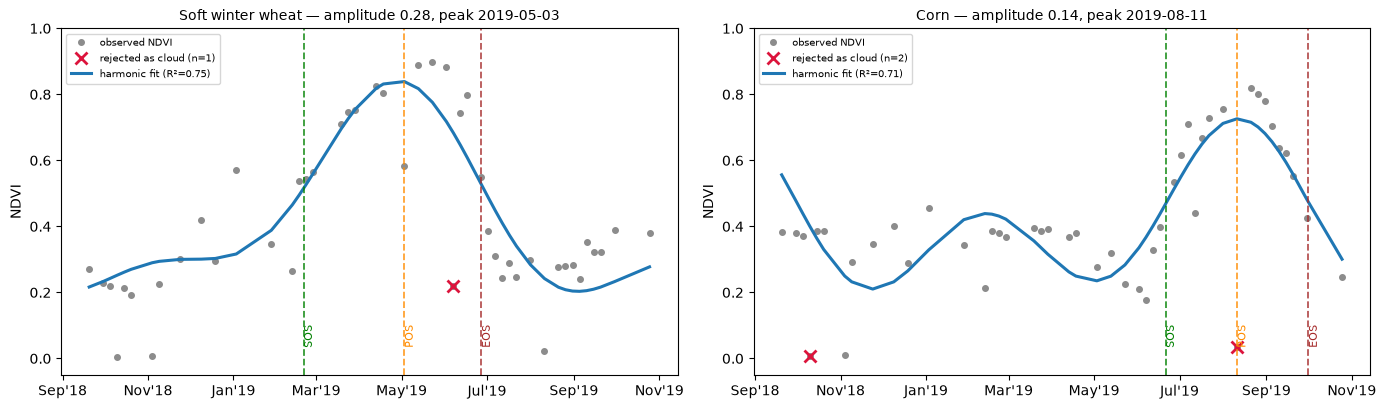

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, cls in zip(axes, [2, 3]):          # soft winter wheat vs corn
    curve = curves[cls]
    f = harmonic_fit(curve, days)
    m = phenology_metrics(curve, days, dates=dates_all)
    ax.plot(dates_all, curve, "o", ms=4, color="0.55", label="observed NDVI")
    if (~f["keep"]).any():
        idx = np.where(~f["keep"])[0]
        ax.plot([dates_all[i] for i in idx], curve[idx], "x", ms=9, color="crimson",
                mew=2, label=f"rejected as cloud (n={len(idx)})")
    ax.plot(dates_all, f["fitted"], "-", lw=2.2, color="#1f77b4",
            label=f"harmonic fit (R²={f['r2']:.2f})")
    for d, lab, col in ((m["sos_date"], "SOS", "green"), (m["peak_date"], "POS", "darkorange"),
                        (m["eos_date"], "EOS", "brown")):
        if d is not None:
            ax.axvline(d, color=col, ls="--", lw=1.3, alpha=0.8)
            ax.text(d, 0.02, f" {lab}", color=col, fontsize=8, rotation=90, va="bottom")
    ax.set_title(f"{class_names[cls]} — amplitude {f['amplitude']:.2f}, peak {m['peak_date']}", fontsize=10)
    ax.set_ylabel("NDVI"); ax.set_ylim(-0.05, 1.0); ax.legend(fontsize=7.5, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))
plt.tight_layout(); plt.show()

The rejected points (red ×) sit at NDVI ≈ 0 in the middle of a growing
season — physically impossible for a green canopy, and exactly the
cloud-contaminated dates flagged independently by the dataset-wide dip
heuristic earlier. The harmonic reconstruction interpolates across them, which
is what makes it usable as a cloud-screening step and not only a descriptor.

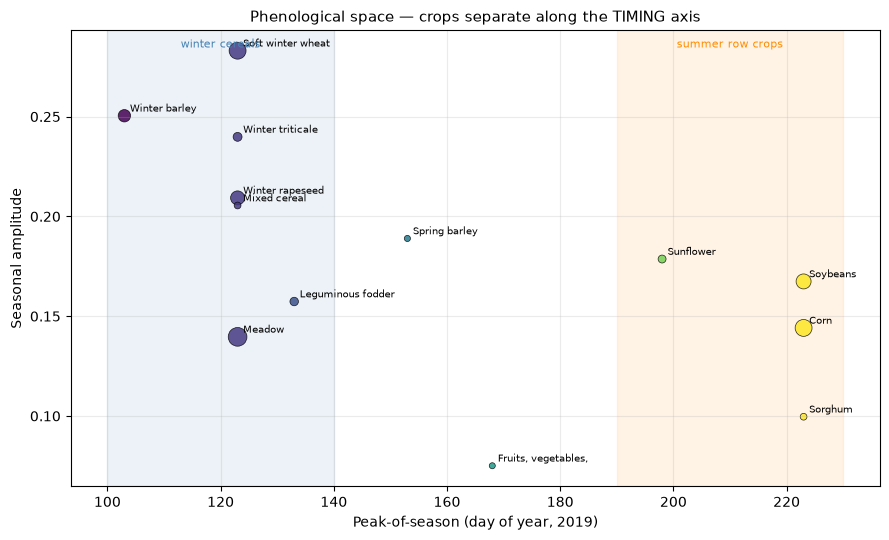

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
peak_doy = [d.timetuple().tm_yday for d in phen.peak_date]
ax.axvspan(100, 140, color="steelblue", alpha=0.10)
ax.axvspan(190, 230, color="darkorange", alpha=0.10)
ax.scatter(peak_doy, phen.amplitude, s=np.sqrt(phen.n_pixels)/3.0,
           c=peak_doy, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.5)
for x, y, n in zip(peak_doy, phen.amplitude, phen.class_name):
    ax.annotate(n[:20], (x, y), fontsize=7.5, xytext=(4, 3), textcoords="offset points")
ax.text(120, ax.get_ylim()[1]*0.97, "winter cereals", ha="center", fontsize=8, color="steelblue")
ax.text(210, ax.get_ylim()[1]*0.97, "summer row crops", ha="center", fontsize=8, color="darkorange")
ax.set_xlabel("Peak-of-season (day of year, 2019)"); ax.set_ylabel("Seasonal amplitude")
ax.set_title("Phenological space — crops separate along the TIMING axis", fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

**This plot is the justification for the delivered model.** Classes are far
better separated horizontally (peak timing) than vertically (amplitude):
amplitude spans a narrow 0.08–0.28 and overlaps heavily between winter and
summer groups, while peak date splits them into two clean clusters 120 days
apart.

A representation that preserves *when* — the ordered NDVI series — can exploit
that horizontal axis. A representation of order-invariant statistics can only
see the vertical one. Section 8 of `report.md` measures the cost of that
choice: **+0.128 macro-F1** from ordering alone, with the model held fixed.

## EDA Summary

- 102 usable patches, single Sentinel-2 tile, uniform 46-observation time
  series (2018-09 to 2019-10), 10 spectral bands, 128x128 px @ 10 m.
- 20 semantic classes present in the label scheme; **severe class
  imbalance** (top 4 classes = ~72% of pixels; several classes <0.1% or
  entirely absent in this subset) → macro-F1 as headline metric, class
  weighting during training.
- Only **semantic** labels are available (no per-parcel instance IDs), so
  classification here is **pixel/patch-level**, not parcel-level.
- Clear, learnable **NDVI phenology signal** separates winter cereals from
  summer row crops — the core feature the traditional-ML track will exploit
  explicitly, and that the DL track must learn implicitly.
- A handful of acquisition dates show dataset-wide NDVI dips consistent with
  **cloud contamination** — a real-world data-quality issue to account for
  in both preprocessing and later error analysis.
- The official PASTIS `Fold` field gives a ready-made, spatially-aware
  5-fold split, used for train/val/test in the next section.

## C. Train / Validation / Test Split

Uses the official PASTIS 5-fold spatial cross-validation assignment
(`Fold` field) rather than a random shuffle, to avoid spatial-neighborhood
leakage between train and held-out patches (see `report.md` §6 for the
full rationale). Generated once by `src/make_splits.py`, saved to
`configs/splits/{train,val,test}.txt` for exact reproducibility.

In [12]:
from model_ml import read_split

train_ids = read_split(cfg, "train")
val_ids = read_split(cfg, "val")
test_ids = read_split(cfg, "test")
print(f"train: {len(train_ids)} patches (folds {cfg['split']['train_folds']})")
print(f"val:   {len(val_ids)} patches (fold {cfg['split']['val_folds']})")
print(f"test:  {len(test_ids)} patches (fold {cfg['split']['test_folds']})")

train: 66 patches (folds [1, 2, 3])
val:   18 patches (fold [4])
test:  18 patches (fold [5])


## D. Model Training

Two independent tracks were trained (full detail and reasoning in
`report.md` §7):

- **Traditional ML** (`src/model_ml.py`, `python train.py --track ml`):
  Random Forest + XGBoost on the 60-dimensional per-pixel temporal-statistics
  feature table from §A, with class-weighted training.
- **Deep learning** (`src/model_dl.py`, `src/train_dl.py`,
  `python train.py --track dl`): a lightweight Temporal-Attention U-Net over
  the raw `(T, C, H, W)` patch tensor (see `report.md` §7.2 for the
  architecture and reasoning). CPU-infeasible to fully train in this
  environment (~8 min/epoch x 40 epochs); intended for a GPU runtime
  (Google Colab instructions in `README.md` §6).

Both tracks were already trained via their respective scripts (heavy
compute deliberately lives in `.py` modules, not inline in this notebook,
so results are reproducible from the command line / CI without a notebook
kernel). This section loads and displays their saved configuration and
results rather than re-running training.

In [13]:
import yaml
print("ML hyperparameters (configs/config.yaml -> model_ml):")
print(yaml.dump(cfg["model_ml"], sort_keys=False))
print("DL hyperparameters (configs/config.yaml -> model_dl):")
print(yaml.dump(cfg["model_dl"], sort_keys=False))

ML hyperparameters (configs/config.yaml -> model_ml):
algorithms:
- random_forest
- xgboost
random_forest:
  n_estimators: 300
  max_depth: 20
  class_weight: balanced
  n_jobs: -1
  random_state: 42
xgboost:
  n_estimators: 400
  max_depth: 8
  learning_rate: 0.05
  tree_method: hist
  random_state: 42

DL hyperparameters (configs/config.yaml -> model_dl):
architecture: unet_temporal
temporal_hidden_dim: 64
unet_base_channels: 32
batch_size: 4
epochs: 40
learning_rate: 0.001
weight_decay: 0.0001
device: cuda



## E. Model Evaluation

**Protocol — crop pixels only.** The task is crop-type classification, so
metrics are computed over pixels whose ground truth is an actual crop
(classes 1–18). Void (19) has no ground truth and background (0) is non-crop
land cover, so neither is a crop-classification outcome. Background remains a
*training* class — the model must be able to output it, or it would be forced
to assign a crop to roads and woodland.

A reference protocol that retains background is saved alongside every result
as `*_withbg_*`; the `accuracy_withbg` / `macro_f1_withbg` columns below show
it. See `report.md` §9.3 for the trade-off (crop-only scoring does not
penalise predicting a crop *on* background land).

All metrics are computed by the same `src/evaluate.py` code for every model,
over the **full** pixel grid of held-out patches (never the training sample).

In [14]:
import pandas as pd
from pathlib import Path

metrics_dir = Path("../outputs/metrics")
comparison = pd.read_csv(metrics_dir / "model_comparison_test.csv")
print("All models — test set, crop-only protocol (sorted by macro-F1):")
comparison

All models — test set, crop-only protocol (sorted by macro-F1):


,track,features,model,accuracy,macro_f1,macro_f1_present_classes,weighted_f1,mean_iou,accuracy_withbg,macro_f1_withbg
0,C (delivered),46 ordered NDVI values,Random Forest,0.8608,0.3696,0.4752,0.8758,0.4452,0.8257,0.3794
1,D,46 ordered NDVI values,TempCNN (1D),0.8240,0.3605,0.4635,0.8514,0.3401,0.7308,0.3520
2,B,"raw (T,C,H,W), 10 bands",Temporal-Attn U-Net,0.7120,0.3398,0.4369,0.7714,0.2981,0.5977,0.3324
3,A,60 temporal statistics,XGBoost,0.7259,0.2802,0.3602,0.7490,0.2682,0.7348,0.2943
4,A,60 temporal statistics,Random Forest,0.6539,0.2419,0.3110,0.6755,0.2337,0.6766,0.2575


**The delivered model (Track C) leads on every metric.** The ordering also
shows the study's central finding: the two tracks using the *ordered NDVI
series* (C and D) occupy the top two places regardless of whether the model is
a tree ensemble or a neural network, while both tracks using 60 temporal
statistics sit at the bottom. Representation separates the results more than
model class does — quantified in `report.md` §8.

In [15]:
delivered = pd.read_csv(metrics_dir / "ndvi_rf_test_per_class.csv")
print("Delivered model (RF on ordered NDVI) — per-class test metrics:")
delivered.sort_values("support", ascending=False)

Delivered model (RF on ordered NDVI) — per-class test metrics:


,class_id,class_name,precision,recall,f1,support
0,1,Meadow,0.938814,0.853290,0.894012,54359
1,2,Soft winter wheat,0.921383,0.933932,0.927615,35388
2,3,Corn,0.916781,0.930595,0.923636,31525
4,5,Winter rapeseed,0.948126,0.923996,0.935905,17328
14,15,Soybeans,0.913040,0.924067,0.918521,13828
3,4,Winter barley,0.939048,0.901104,0.919685,11780
6,7,Sunflower,0.943128,0.698001,0.802258,2851
11,12,"Fruits, vegetables, flowers",0.000000,0.000000,0.000000,2643
13,14,Leguminous fodder,0.653226,0.182227,0.284960,1778
9,10,Winter triticale,0.066986,0.034739,0.045752,1612


Every crop class with more than 10K test pixels — 93.9% of the cropped area —
scores F1 between 0.89 and 0.94. The near-zero rows are classes with almost no
test support, and four classes have **zero** test pixels and are scored 0 by
construction. `report.md` §10.1 decomposes exactly how much of macro-F1 that
accounts for.

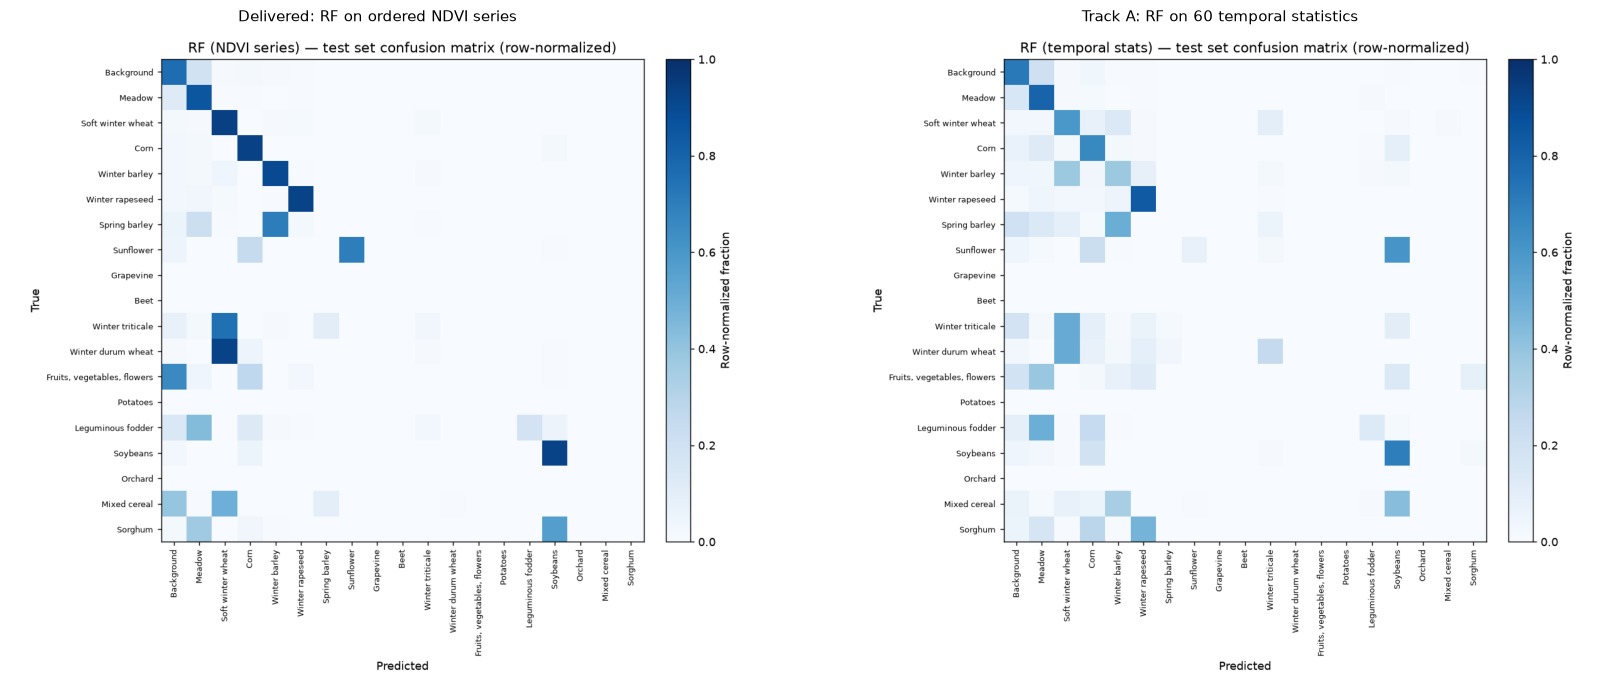

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, tag, title in zip(
    axes,
    ["ndvi_rf", "ml_rf"],
    ["Delivered: RF on ordered NDVI series", "Track A: RF on 60 temporal statistics"],
):
    p = Path(f"../outputs/figures/confusion_matrix_{tag}_test.png")
    if p.exists():
        ax.imshow(mpimg.imread(p))
        ax.set_title(title, fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.show()

Side by side, the same Random Forest on the two representations. The ordered
NDVI series produces a far cleaner diagonal; the temporal-statistics version
scatters mass off-diagonal, especially among the winter cereals whose
distinguishing information is *when* they peak — precisely what
order-invariant statistics discard.

## F. Visualization of Outputs

Sentinel-2 RGB | ground truth | prediction, for a few test patches, one
column per model (`src/visualization.py`).

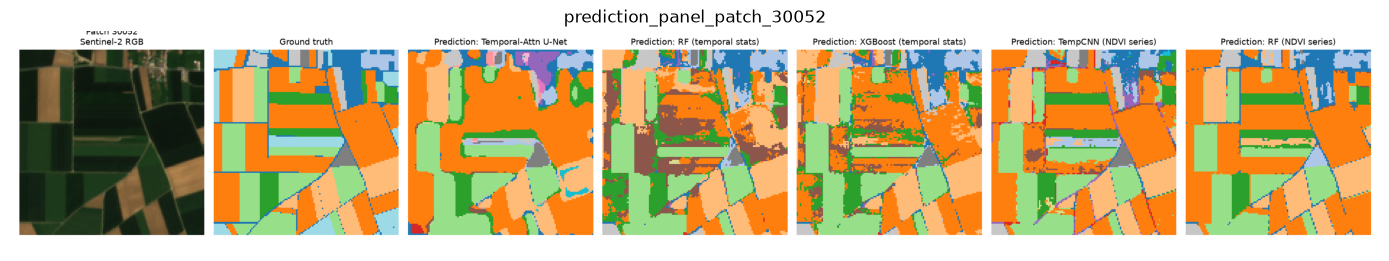

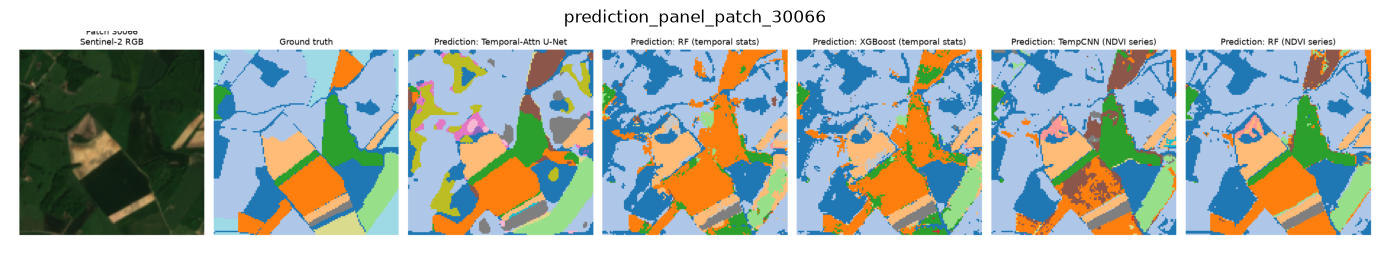

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

panel_paths = sorted(Path("../outputs/figures").glob("prediction_panel_patch_*.png"))
for p in panel_paths[:2]:
    fig, ax = plt.subplots(figsize=(14, 3.2))
    ax.imshow(mpimg.imread(p))
    ax.axis("off")
    ax.set_title(p.stem)
    plt.tight_layout()
    plt.show()

## G. Analysis & Interpretation

Full discussion — model choice rationale, strengths/limitations, per-class
error analysis, effects of class imbalance and cloud contamination, AOI
context, and recommended next steps — is written up in **`report.md`**
(§10), which is the primary deliverable for this section.